## Import libraries

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks

## Load data

In [19]:
# file_path = '/Users/hamida/Desktop/BackgroundMover/pdtracesig3_2025-09-30_001_0001.h5'
file_path = '/Volumes/otopaliklab/Temporary_Storage/Aisha/Unity frames test data/10_03_2025_comparing builds/movie_led_stimulus/movietest2_0001.h5'

In [20]:
with h5py.File(file_path, 'r') as f:
    # Load analog signal data
    analog_data = f['sweep_0001/analogScans'][:]
    
    # Load acquisition sample rate
    sample_rate = f['header/AcquisitionSampleRate'][()][0][0]
    
    # Load timestamp (start time)
    start_time = f['sweep_0001/timestamp'][()][0][0]
    
    # Load channel names
    channel_names = [name.decode('utf-8') for name in f['header/AIChannelNames'][:]]

## Visualize data shape

In [21]:
print(f"Analog data shape: {analog_data.shape}")  # Should be (4, N)
print(f"Sample rate: {sample_rate} Hz")
print(f"Start time: {start_time} s")
print(f"Channel names: {channel_names}")

Analog data shape: (4, 6338061)
Sample rate: 10000.0 Hz
Start time: 0.46606990000000004 s
Channel names: ['Arena Frame Clock', 'Animal Heading', 'Photodiode', '2P Frame Clock']


In [22]:
# Get Arena Frame Clock signal
arena_clock = analog_data[0]

# Find the index of the first rising edge (signal changes from low to high)
threshold = 10000  # adjust if needed, depending on signal range
rising_edges = np.where((arena_clock[:-1] < threshold) & (arena_clock[1:] >= threshold))[0]

if len(rising_edges) == 0:
    print("No rising edge found in Arena Frame Clock.")
else:
    first_step_index = rising_edges[0] + 1  # +1 to get the index after the threshold crossing
    first_step_time = start_time + first_step_index / sample_rate
    print(f"First step occurs at index {first_step_index}, time {first_step_time:.6f} seconds.")


First step occurs at index 66140, time 7.080070 seconds.


In [23]:
total_samples = analog_data.shape[1]
time = np.arange(total_samples) / sample_rate + start_time

/var/folders/nz/36wz0cz90t34jt3ryz6_n08w0000gp/T/ipykernel_70588/3358136908.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/opt/anaconda3/envs/unityvr/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


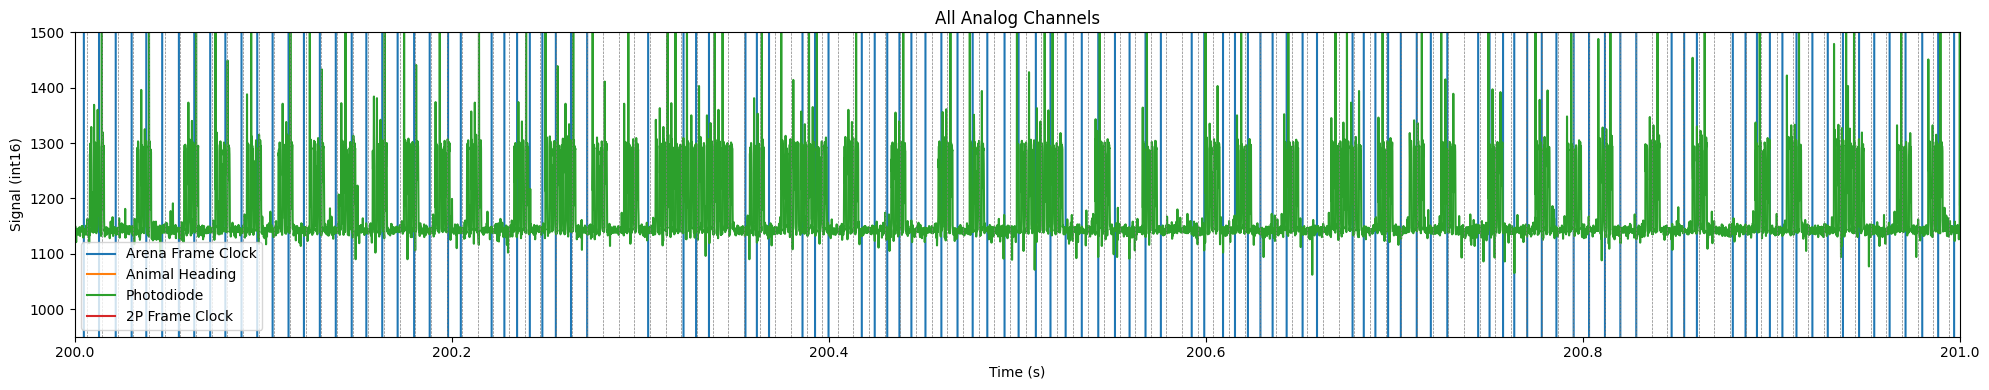

In [24]:
plt.figure(figsize=(20, 4))
for i, channel in enumerate(channel_names):
    plt.plot(time, analog_data[i], label=channel)


# Get the min and max of x-axis (time)
x_start = time.min()
x_end = time.max()


# Create ticks every 0.0083 units
x_ticks = np.arange(x_start, x_end, 0.0083)

for x in x_ticks:
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.5)


plt.xlabel("Time (s)")
plt.ylabel("Signal (int16)")
plt.title("All Analog Channels")
plt.legend()
plt.grid(False)

plt.xlim(200, 201)
plt.ylim(950, 1500)

plt.tight_layout()
plt.show()


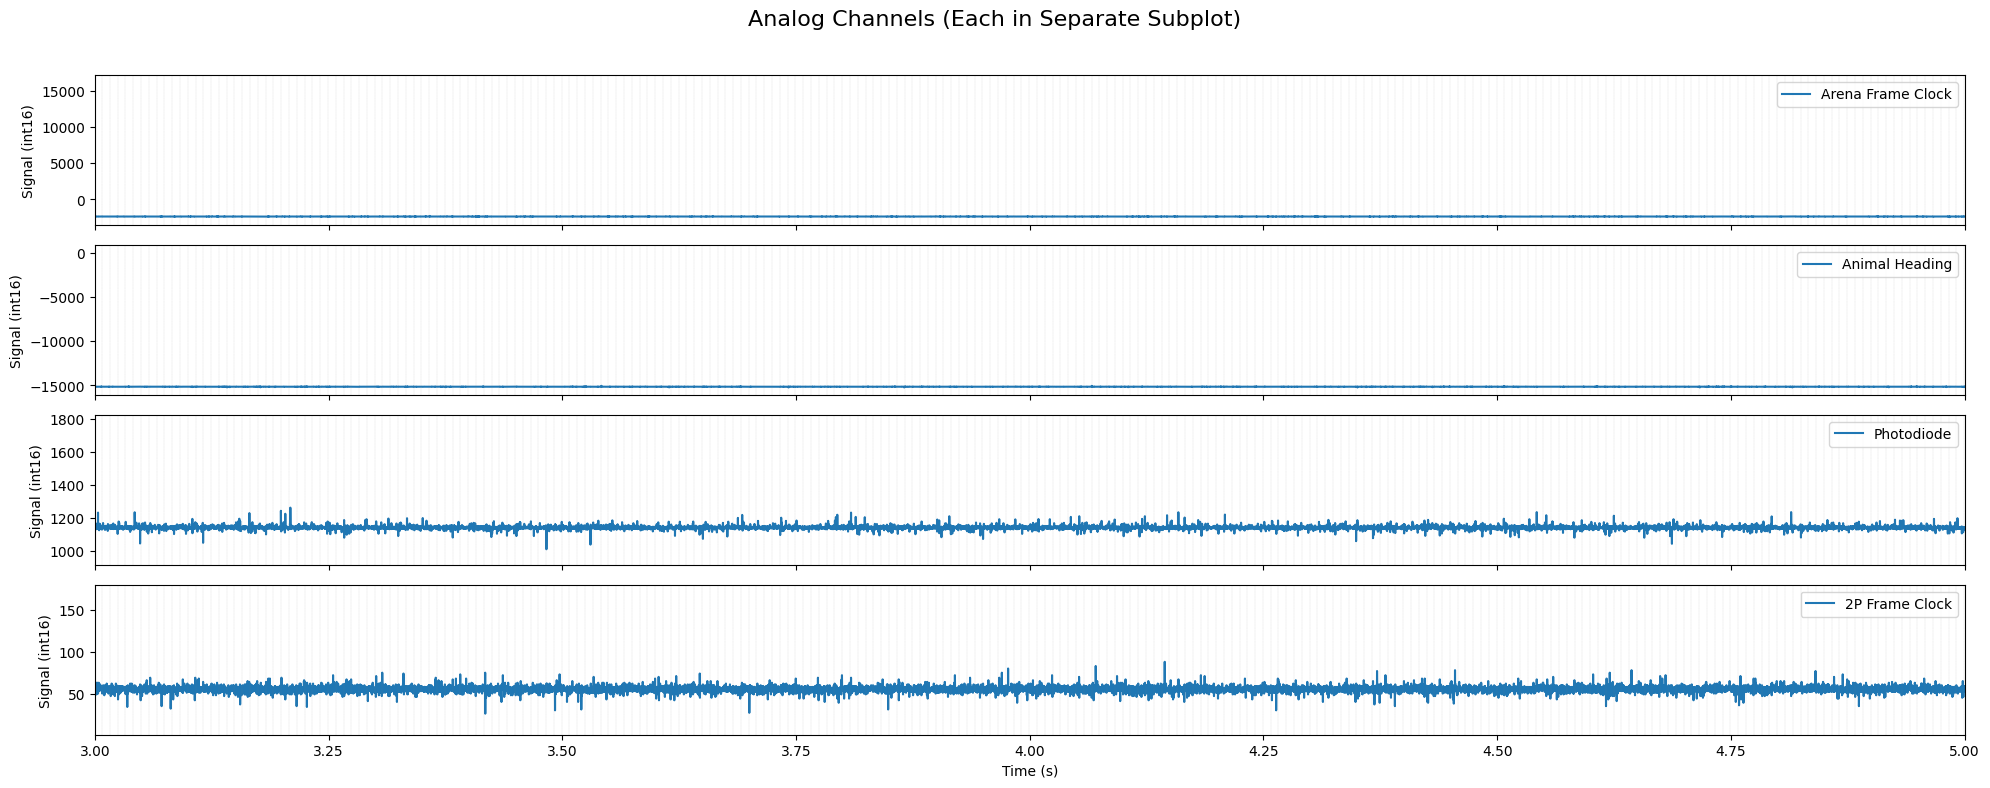

In [25]:
# Number of channels
n_channels = len(channel_names)

# Create subplots
fig, axes = plt.subplots(n_channels, 1, figsize=(20, 2 * n_channels), sharex=True)

for i, channel in enumerate(channel_names):
    axes[i].plot(time, analog_data[i], label=channel)
    axes[i].set_ylabel("Signal (int16)")
    axes[i].legend(loc='upper right')
    axes[i].grid(False)

    # Add vertical frame lines (every 1/120 sec)
    for x in np.arange(time.min(), time.max(), 1 / 120):
        axes[i].axvline(x=x, color='gray', linestyle='--', linewidth=0.1)

# Shared X-axis settings
axes[-1].set_xlabel("Time (s)")
fig.suptitle("Analog Channels (Each in Separate Subplot)", fontsize=16)
plt.xlim(3, 5)
# plt.ylim(1700, 2200)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle
plt.show()


### Detect peaks/frames

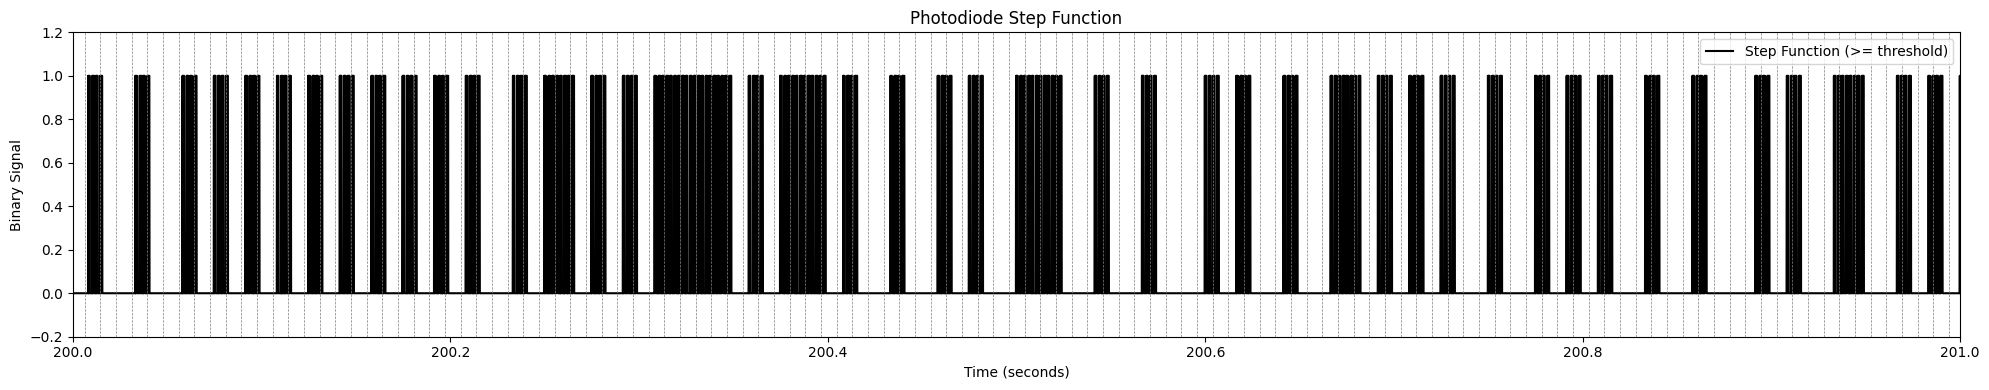

In [26]:
# Extract photodiode signal
photodiode_channel_index = channel_names.index("Photodiode")
photodiode_signal = analog_data[photodiode_channel_index]

# Create binary step function
threshold = 1250
step_signal = (photodiode_signal >= threshold).astype(int)

# Plot the step function
plt.figure(figsize=(20, 4))
plt.plot(time, step_signal, label="Step Function (>= threshold)", color='black')

plt.xlabel("Time (seconds)")
plt.ylabel("Binary Signal")
plt.title("Photodiode Step Function")
plt.grid(False)


# Get the min and max of x-axis (time)
x_start = time.min()
x_end = time.max()


# Create ticks every 0.0083 units
x_ticks = np.arange(x_start, x_end, 0.0083)

for x in x_ticks:
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.5)

plt.xlim(200, 201)
plt.ylim(-0.2, 1.2)
plt.tight_layout()
plt.legend()
plt.show()

/var/folders/nz/36wz0cz90t34jt3ryz6_n08w0000gp/T/ipykernel_70588/4178241384.py:62: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


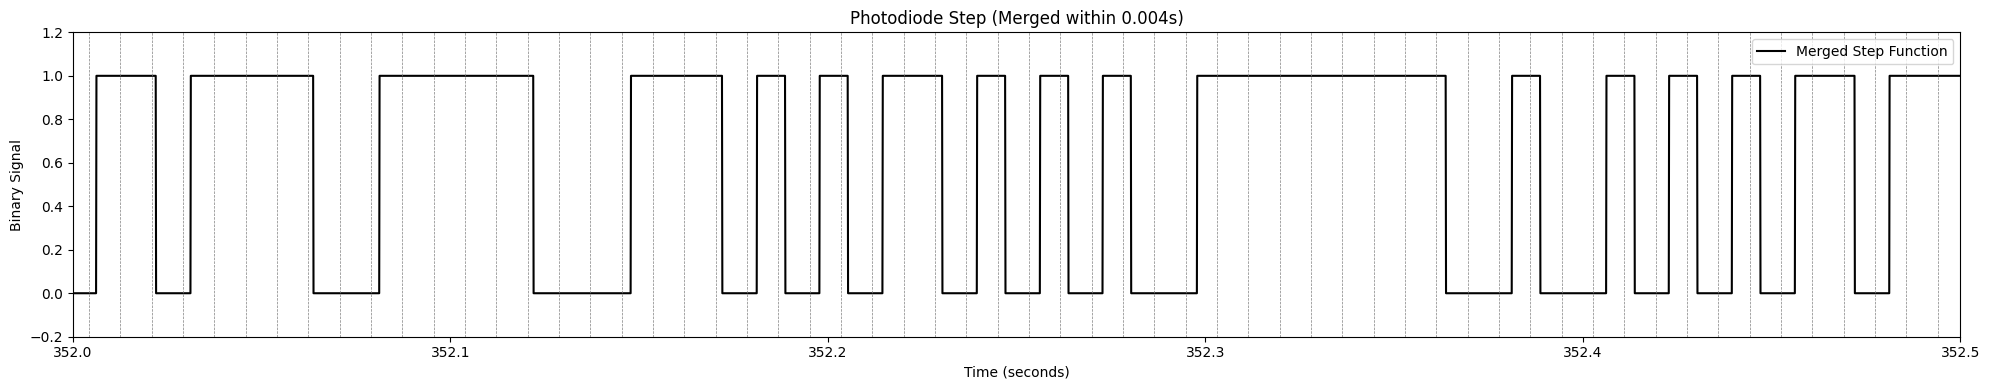

In [27]:
# Step 1: Get indices where signal changes
step_diff = np.diff(step_signal)
rising_edges = np.where(step_diff == 1)[0] + 1
falling_edges = np.where(step_diff == -1)[0] + 1

# Step 2: Ensure rising and falling pairs are matched correctly
if falling_edges[0] < rising_edges[0]:
    falling_edges = falling_edges[1:]
if len(rising_edges) > len(falling_edges):
    rising_edges = rising_edges[:-1]

# Step 3: Merge close 1-intervals (gap < 0.004 sec)
merged_intervals = []
min_gap = 0.004  # seconds

i = 0
while i < len(rising_edges):
    start_idx = rising_edges[i]
    end_idx = falling_edges[i]

    # Merge forward if next rise is close
    while (i + 1 < len(rising_edges)) and ((time[rising_edges[i + 1]] - time[falling_edges[i]]) < min_gap):
        end_idx = falling_edges[i + 1]
        i += 1

    merged_intervals.append((start_idx, end_idx))
    i += 1

# Step 4: Create compressed step signal
compressed_step = np.zeros_like(step_signal)

# for start, end in merged_intervals:
#     compressed_step[start:end] = 1

for start, end in merged_intervals:
    if time[end] - time[start] >= 0.006:
        compressed_step[start:end] = 1

# Step 5: Plot compressed step signal
plt.figure(figsize=(20, 4))
plt.plot(time, compressed_step, label="Merged Step Function", color='black')
plt.xlabel("Time (seconds)")
plt.ylabel("Binary Signal")
plt.title("Photodiode Step (Merged within 0.004s)")
plt.grid(False)

# Get the min and max of x-axis (time)
x_start = time.min()
x_end = time.max()


# Create ticks every 0.0083 units
x_ticks = np.arange(x_start, x_end, 0.0083)

for x in x_ticks:
    plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.5)


plt.xlim(352, 352.5)
plt.ylim(-0.2, 1.2)
plt.legend()
plt.tight_layout()
plt.show()


In [28]:
# Step durations from compressed step function
durations = []

current_value = compressed_step[0]
start_idx = 0

for i in range(1, len(compressed_step)):
    if compressed_step[i] != current_value:
        end_idx = i
        start_time = time[start_idx]
        end_time = time[end_idx]
        duration = end_time - start_time

        durations.append({
            "start_time": start_time,
            "end_time": end_time,
            "duration": duration,
            "value": current_value  # 0 = black, 1 = white
        })

        start_idx = i
        current_value = compressed_step[i]

# Add the last segment
start_time = time[start_idx]
end_time = time[-1]
duration = end_time - start_time
durations.append({
    "start_time": start_time,
    "end_time": end_time,
    "duration": duration,
    "value": current_value
})

# Create DataFrame
df_durations = pd.DataFrame(durations)


In [29]:
df_durations

,start_time,end_time,duration,value
0,0.46607,7.16897,6.7029,0
1,7.16897,7.19317,0.0242,1
2,7.19317,7.21067,0.0175,0
3,7.21067,7.22647,0.0158,1
4,7.22647,7.23567,0.0092,0
...,...,...,...,...
49442,613.78547,613.79467,0.0092,0
49443,613.79467,613.80217,0.0075,1
49444,613.80217,613.81127,0.0091,0
49445,613.81127,613.81887,0.0076,1


In [30]:
# Define frame duration
frame_duration = 1 / 120  # ≈ 0.00833 s

# Add frame count and label
df_durations["n_frames"] = (df_durations["duration"] / frame_duration).round().astype(int)
df_durations["label"] = df_durations["value"].map({1: "white", 0: "black"})


In [31]:
df_durations

,start_time,end_time,duration,value,n_frames,label
0,0.46607,7.16897,6.7029,0,804,black
1,7.16897,7.19317,0.0242,1,3,white
2,7.19317,7.21067,0.0175,0,2,black
3,7.21067,7.22647,0.0158,1,2,white
4,7.22647,7.23567,0.0092,0,1,black
...,...,...,...,...,...,...
49442,613.78547,613.79467,0.0092,0,1,black
49443,613.79467,613.80217,0.0075,1,1,white
49444,613.80217,613.81127,0.0091,0,1,black
49445,613.81127,613.81887,0.0076,1,1,white


In [32]:
# Identify dropped frame events
drop_events = df_durations[df_durations["n_frames"] > 1].copy()

# Compute how many frames were dropped
drop_events["n_dropped"] = drop_events["n_frames"] - 1

# Compute midpoint time for plotting
drop_events["mid_time"] = (drop_events["start_time"] + drop_events["end_time"]) / 2


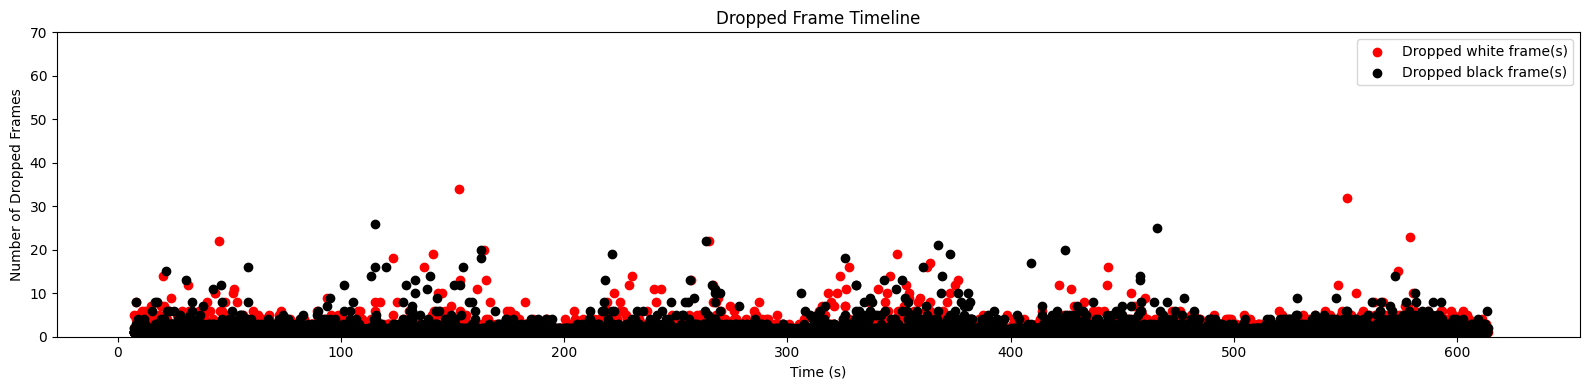

In [33]:
plt.figure(figsize=(16, 4))

# Plot by type
for drop_type, color in [("white", "red"), ("black", "black")]:
    subset = drop_events[drop_events["label"] == drop_type]
    plt.scatter(subset["mid_time"], subset["n_dropped"], color=color, label=f"Dropped {drop_type} frame(s)")

plt.xlabel("Time (s)")
plt.ylabel("Number of Dropped Frames")
plt.title("Dropped Frame Timeline")
plt.grid(False)
# plt.xlim(6, 77)
plt.ylim(0, 70)
plt.legend()
plt.tight_layout()
plt.show()


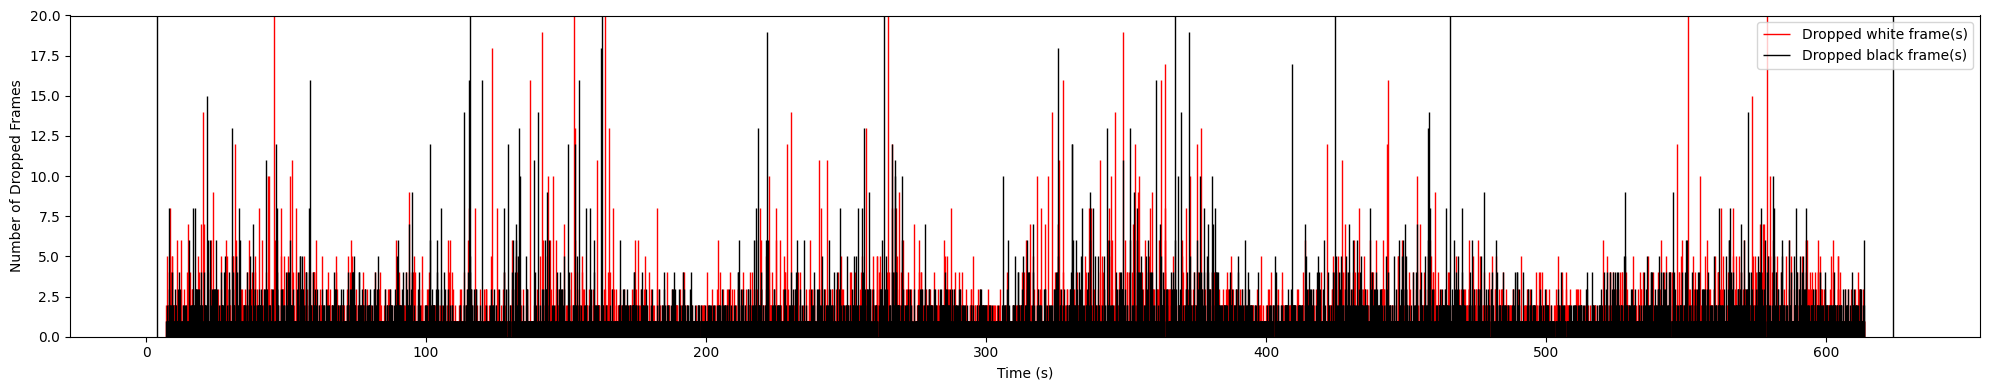

In [34]:
plt.figure(figsize=(20, 4))

# Plot vertical lines per type
for drop_type, color in [("white", "red"), ("black", "black")]:
    subset = drop_events[drop_events["label"] == drop_type]
    plt.vlines(x=subset["mid_time"],
               ymin=0,
               ymax=subset["n_dropped"],
               color=color,
               label=f"Dropped {drop_type} frame(s)",
               linewidth=1)

plt.xlabel("Time (s)")
plt.ylabel("Number of Dropped Frames")
# plt.title("Dropped Frame Timeline (One Line per Event)")
plt.grid(False)


# # Get the min and max of x-axis (time)
# x_start = time.min()
# x_end = time.max()


# # Create ticks every 0.0083 units
# x_ticks = np.arange(x_start, x_end, 0.0083)

# for x in x_ticks:
#     plt.axvline(x=x, color='gray', linestyle='--', linewidth=0.5)


# plt.xlim(352, 352.5)
plt.ylim(0, 20)

plt.legend()
plt.tight_layout()
plt.show()
